# Решение нелинейного уравнения

Нужно найти корень уравнения 3x + cos(x) - 1 = 0 с точностью 0.0001.

Обозначим левую часть уравнения как f(x):
f(x) = 3x + cos(x) - 1.

Для начала выберем отрезок, на котором находится корень. Возьмём [-0.2; 0.1].

На концах этого отрезка значения функции разные по знаку:
f(-0.2) примерно равно -0.619933,
f(0.1) примерно равно 0.295004.

Значит, между -0.2 и 0.1 есть корень.

Производная функции равна f'(x) = 3 - sin(x). Она всегда больше нуля, поэтому функция возрастает. Из этого следует, что корень на выбранном отрезке только один.

Можно сразу заметить, что при x = 0 получается f(0) = 0. То есть точный корень равен 0, а ниже я проверю это численными методами.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eps = 1e-4
a0, b0 = -0.2, 0.1

def f(x):
    return 3 * x + math.cos(x) - 1

def df(x):
    return 3 - math.sin(x)

def ddf(x):
    return -math.cos(x)

def phi(x):
    return (1 - math.cos(x)) / 3

def dphi(x):
    return math.sin(x) / 3

def fmt_root(x, digits=4):
    if abs(x) < 0.5 * 10**(-digits):
        x = 0.0
    return f"{x:.{digits}f}"

print(f"f({a0}) = {f(a0):.6f}")
print(f"f({b0}) = {f(b0):.6f}")
print(f"f(0) = {f(0):.6f}")

f(-0.2) = -0.619933
f(0.1) = 0.295004
f(0) = 0.000000


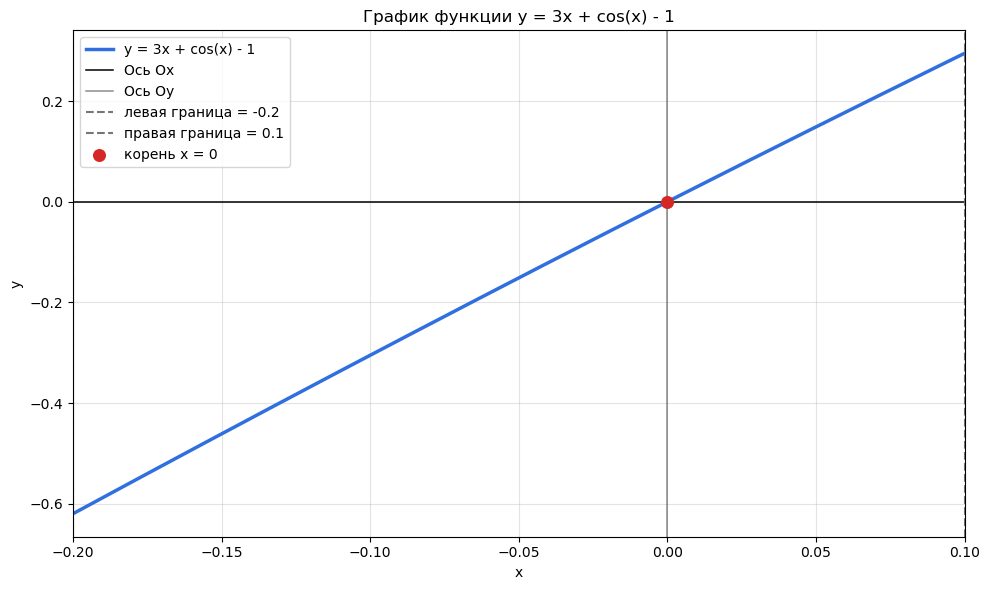

In [2]:
x = np.linspace(a0, b0, 400)
y = 3 * x + np.cos(x) - 1

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, color="#2f6fdf", linewidth=2.5, label="y = 3x + cos(x) - 1")

ax.axhline(0, color="black", linewidth=1.1, label="Ось Ox")
ax.axvline(0, color="black", linewidth=1.1, alpha=0.45, label="Ось Oy")
ax.axvline(a0, color="#777777", linestyle="--", linewidth=1.5, label=f"левая граница = {a0}")
ax.axvline(b0, color="#777777", linestyle="--", linewidth=1.5, label=f"правая граница = {b0}")
ax.scatter([0], [0], color="#d62728", s=70, zorder=5, label="корень x = 0")

ax.set_title("График функции y = 3x + cos(x) - 1")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(a0, b0)
ax.grid(True, alpha=0.35)
ax.legend()
fig.tight_layout()
plt.show()

## 1. Метод дихотомии

В этом методе отрезок каждый раз делится пополам.

Середина отрезка считается так:
c = (a + b) / 2.

После этого смотрим, где меняется знак функции. Если знак меняется между a и c, то дальше работаем с этим отрезком. Иначе берём отрезок от c до b.

Останавливаем вычисления, когда длина отрезка становится не больше 2 * eps. Тогда середина отрезка уже даёт нужную точность.

In [3]:
def bisection_method(a, b, eps):
    rows = []
    k = 1

    while True:
        c = (a + b) / 2
        fc = f(c)

        rows.append({
            "k": k,
            "a": a,
            "b": b,
            "c": c,
            "f(c)": fc,
            "|b-a|": abs(b - a)
        })

        if abs(fc) < 1e-14:
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c

        if abs(b - a) <= 2 * eps:
            break

        k += 1

    return pd.DataFrame(rows), (a + b) / 2

table_bis, root_bis = bisection_method(a0, b0, eps)
display(table_bis)
print(f"Ответ методом дихотомии: x = {fmt_root(root_bis, 6)}")
print(f"С точностью 1e-4: x = {fmt_root(root_bis, 4)}")

,k,a,b,c,f(c),|b-a|
0,1,-0.200000,0.100000,-0.050000,-0.151250,0.300000
1,2,-0.050000,0.100000,0.025000,0.074688,0.150000
2,3,-0.050000,0.025000,-0.012500,-0.037578,0.075000
3,4,-0.012500,0.025000,0.006250,0.018730,0.037500
4,5,-0.012500,0.006250,-0.003125,-0.009380,0.018750
5,6,-0.003125,0.006250,0.001563,0.004686,0.009375
6,7,-0.003125,0.001563,-0.000781,-0.002344,0.004688
7,8,-0.000781,0.001563,0.000391,0.001172,0.002344
8,9,-0.000781,0.000391,-0.000195,-0.000586,0.001172
9,10,-0.000195,0.000391,0.000098,0.000293,0.000586


Ответ методом дихотомии: x = 0.000024
С точностью 1e-4: x = 0.0000


## 2. Метод хорд

В методе хорд через две точки графика проводится прямая. Затем берётся точка, где эта прямая пересекает ось Ox.

Формула для нового приближения:
x = a - f(a) * (b - a) / (f(b) - f(a)).

После нахождения x снова выбираем ту часть отрезка, где функция меняет знак.

Останавливаемся, когда два соседних значения x отличаются меньше чем на eps.

In [4]:
def chord_method(a, b, eps):
    rows = []
    prev_x = None
    k = 1

    while True:
        fa, fb = f(a), f(b)
        x = a - fa * (b - a) / (fb - fa)
        fx = f(x)
        dx = None if prev_x is None else abs(x - prev_x)

        rows.append({
            "k": k,
            "a": a,
            "b": b,
            "x": x,
            "f(x)": fx,
            "|x_k-x_(k-1)|": dx
        })

        if dx is not None and dx <= eps:
            break

        if fa * fx > 0:
            a = x
        else:
            b = x

        prev_x = x
        k += 1

    return pd.DataFrame(rows), x

table_chord, root_chord = chord_method(a0, b0, eps)
display(table_chord)
print(f"Ответ методом хорд: x = {fmt_root(root_chord, 6)}")
print(f"С точностью 1e-4: x = {fmt_root(root_chord, 4)}")

,k,a,b,x,f(x),|x_k-x_(k-1)|
0,1,-0.2,0.100000,3.270725e-03,9.806826e-03,NaN
1,2,-0.2,0.003271,1.052283e-04,3.156794e-04,0.003165
2,3,-0.2,0.000105,3.383588e-06,1.015076e-05,0.000102
3,4,-0.2,0.000003,1.087964e-07,3.263893e-07,0.000003


Ответ методом хорд: x = 0.000000
С точностью 1e-4: x = 0.0000


## 3. Метод касательных

Метод касательных ещё называют методом Ньютона.

На каждом шаге новое значение считается по формуле:
x_new = x - f(x) / f'(x).

В качестве начального значения берём x = -0.2. На этом конце отрезка условие для метода выполняется: значение функции отрицательное, а вторая производная на выбранном отрезке тоже отрицательная.

Останавливаемся, когда разница между новым и предыдущим значением становится меньше eps.

In [5]:
def newton_method(x0, eps):
    rows = []
    k = 1

    while True:
        x1 = x0 - f(x0) / df(x0)

        rows.append({
            "k": k,
            "x_k": x0,
            "f(x_k)": f(x0),
            "f'(x_k)": df(x0),
            "x_(k+1)": x1,
            "|x_(k+1)-x_k|": abs(x1 - x0),
            "f(x_(k+1))": f(x1)
        })

        if abs(x1 - x0) <= eps:
            break

        x0 = x1
        k += 1

    return pd.DataFrame(rows), x1

table_newton, root_newton = newton_method(a0, eps)
display(table_newton)
print(f"Ответ методом касательных: x = {fmt_root(root_newton, 6)}")
print(f"С точностью 1e-4: x = {fmt_root(root_newton, 4)}")

,k,x_k,f(x_k),f'(x_k),x_(k+1),|x_(k+1)-x_k|,f(x_(k+1))
0,1,-0.200000,-0.619933,3.198669,-6.190213e-03,0.193810,-1.858980e-02
1,2,-0.006190,-0.018590,3.006190,-6.373244e-06,0.006184,-1.911975e-05
2,3,-0.000006,-0.000019,3.000006,-6.769716e-12,0.000006,-2.030920e-11


Ответ методом касательных: x = 0.000000
С точностью 1e-4: x = 0.0000


## 4. Метод простых итераций

Сначала перепишем уравнение так, чтобы x стоял отдельно:
3x = 1 - cos(x),
x = (1 - cos(x)) / 3.

Значит, для итераций используем функцию:
phi(x) = (1 - cos(x)) / 3.

Производная этой функции равна:
phi'(x) = sin(x) / 3.

На выбранном отрезке максимальное значение |phi'(x)| примерно равно 0.066223. Это меньше 1, поэтому метод должен сходиться.

Начинаем с x = 0.1. Остановку делаем по оценке ошибки, которая считается в коде ниже.

In [6]:
def iteration_method(x0, eps):
    q = max(abs(math.sin(a0)) / 3, abs(math.sin(b0)) / 3)

    rows = []
    k = 1

    while True:
        x1 = phi(x0)
        diff = abs(x1 - x0)
        error_estimate = q / (1 - q) * diff

        rows.append({
            "k": k,
            "x_k": x0,
            "x_(k+1)=phi(x_k)": x1,
            "|x_(k+1)-x_k|": diff,
            "q/(1-q)*|dx|": error_estimate,
            "f(x_(k+1))": f(x1)
        })

        if error_estimate <= eps:
            break

        x0 = x1
        k += 1

    return pd.DataFrame(rows), x1, q

table_iter, root_iter, q = iteration_method(0.1, eps)
print(f"q = {q:.6f}")
display(table_iter)
print(f"Ответ методом простых итераций: x = {fmt_root(root_iter, 6)}")
print(f"С точностью 1e-4: x = {fmt_root(root_iter, 4)}")

q = 0.066223


,k,x_k,x_(k+1)=phi(x_k),|x_(k+1)-x_k|,q/(1-q)*|dx|,f(x_(k+1))
0,1,1.000000e-01,1.665278e-03,9.833472e-02,6.973862e-03,4.994448e-03
1,2,1.665278e-03,4.621918e-07,1.664816e-03,1.180681e-04,1.386575e-06
2,3,4.621918e-07,3.560115e-14,4.621918e-07,3.277847e-08,1.068035e-13


Ответ методом простых итераций: x = 0.000000
С точностью 1e-4: x = 0.0000


## Итог

Все четыре метода дали значение, которое при округлении до четырёх знаков после запятой равно 0.0000.

Это совпадает с точным ответом, потому что при x = 0 исходное уравнение выполняется.

Ответ: x = 0.

In [7]:
roots = [root_bis, root_chord, root_newton, root_iter]

summary = pd.DataFrame({
    "Метод": ["Дихотомии", "Хорд", "Касательных", "Простых итераций"],
    "Приближённый корень": [fmt_root(x, 6) for x in roots],
    "До 4 знаков": [fmt_root(x, 4) for x in roots]
})

display(summary)

,Метод,Приближённый корень,До 4 знаков
0,Дихотомии,0.000024,0.0000
1,Хорд,0.000000,0.0000
2,Касательных,0.000000,0.0000
3,Простых итераций,0.000000,0.0000
